# Employee Attrition Analysis 
## Part 1: Exploratory Data Analysis
**Author:** Fariz Yusri  
**Date:** May 2026

## 1. Load the excel first 



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load the excel data
df = pd.read_excel(r'Employee_Attrition_Date.xlsx')

print(f'Data: {df.shape[0]:,} No. of employees with {df.shape[1]} features')
print(f'Total Missing Values: {df.isnull().sum().sum()}') #blanks on excel shows none anyways but double check
df.head()

Data: 1,470 No. of employees with 31 features
Total Missing Values: 0


,EmployeeNumber,Attrition,Age,DailyRate,Department,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,Yes,41,1102,Sales,1,2,2,Female,94,...,1,80,0,8,0,1,6,4,0,5
1,2,No,49,279,Research & Development,8,1,3,Male,61,...,4,80,1,10,3,3,10,7,1,7
2,4,Yes,37,1373,Research & Development,2,2,4,Male,92,...,2,80,0,7,3,3,0,0,0,0
3,5,No,33,1392,Research & Development,3,4,4,Female,56,...,3,80,0,8,3,3,8,7,3,0
4,7,No,27,591,Research & Development,2,1,1,Male,40,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.describe(include='all').T #just to check the data types and get a quick overview of the data, will do more detailed EDA later

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EnvironmentSatisfaction,1470.0,NaN,NaN,NaN,2.721769,1.093082,1.0,2.0,3.0,4.0,4.0
Gender,1470,2,Male,882,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HourlyRate,1470.0,NaN,NaN,NaN,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0


## 2. Feature Engineering of Attrition and Overall Attrition Rate 

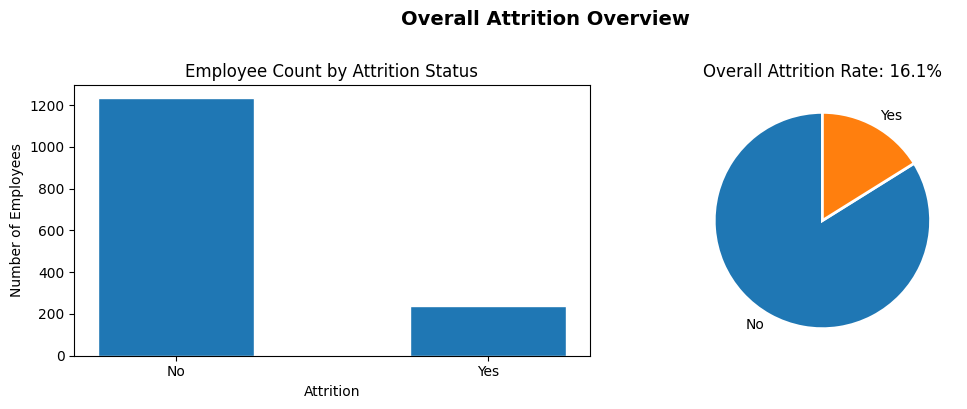


Overall attrition rate: 16.1%
Employees who stayed : 1233
Employees who left   : 237


In [ ]:
# Attrition is given as "Yes/No", change to 0s and 1s 
df['AttritionBinary'] = (df['Attrition'] == 'Yes').astype(int)

overall_rate = df['AttritionBinary'].mean() * 100 #add all the 1s and divide by total to get percentage aka mean 
counts = df['Attrition'].value_counts() #count the number of "Yes" and "No" in the original "Attrition" column for the bar chart and pie chart

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Plot a Bar chart
axes[0].bar(counts.index, counts.values, width=0.5, edgecolor='white')
axes[0].set_title('Employee Count by Attrition Status')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Number of Employees')

# Plot a Pie chart
axes[1].pie(counts.values, labels=counts.index, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title(f'Overall Attrition Rate: {overall_rate:.1f}%')

plt.suptitle('Overall Attrition Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'\nOverall attrition rate: {overall_rate:.1f}%')
print(f'Employees who stayed : {counts["No"]}')
print(f'Employees who left   : {counts["Yes"]}')

### Exploring Department 

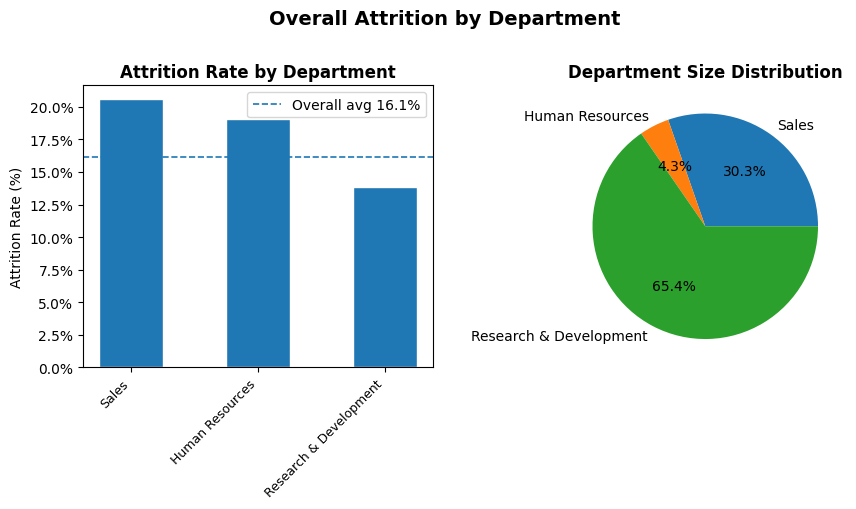

            Department  total  left  attrition_rate      size
                 Sales    446    92       20.627803 30.340136
       Human Resources     63    12       19.047619  4.285714
Research & Development    961   133       13.839750 65.374150


In [ ]:
#create dept_stats dataframe with total employees, number of employees who left and attrition rate by department, then sort by attrition rate in descending order
dept_stats = (
    df.groupby('Department')['AttritionBinary']
    .agg(total = 'count', left= 'sum') #total is the count of all employees in one department 
    .assign(attrition_rate = lambda x: x['left'] / x['total']*100)
    .sort_values('attrition_rate', ascending = False)
    .reset_index()
) 

# create values to visualise the department sizes 
dept_stats['size'] = dept_stats['total'] / dept_stats['total'].sum() * 100

#plot bar chart of attrition rate by department, and the department sizes 
fig, ax = plt.subplots(1,2, figsize=(9, 5))

ax[0].bar(dept_stats['Department'], dept_stats['attrition_rate'], edgecolor='white', width=0.5)
ax[0].set_xticklabels(dept_stats['Department'], rotation=45, ha='right', fontsize=9)
# Overall benchmark line
ax[0].axhline(overall_rate, linestyle='--', linewidth=1.2, label=f'Overall avg {overall_rate:.1f}%')
ax[0].legend(fontsize=10)

ax[0].set_ylabel('Attrition Rate (%)')
ax[0].set_title('Attrition Rate by Department', fontweight='bold')
ax[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# plot 
ax[1].pie(dept_stats['size'], labels=dept_stats['Department'], autopct='%1.1f%%')
ax[1].set_title('Department Size Distribution', fontweight='bold')

plt.suptitle('Overall Attrition by Department', fontsize=14, fontweight='bold', y=1.01)


plt.tight_layout()
plt.show()

print(dept_stats.to_string(index=False))

**Insight:** From this EDA, we can observe that the Sales department has the highest attrition rate, followed by Human Resources. Research & Development (which is the largest department) is found to be below the overall average, suggesting better retention in research/technical roles.

### Exploring Demographic Factors

In [ ]:
print(f'Youngest employee age: {df["Age"].min()}')
print(f'Oldest employee age: {df["Age"].max()}')

Youngest employee age: 18
Oldest employee age: 60


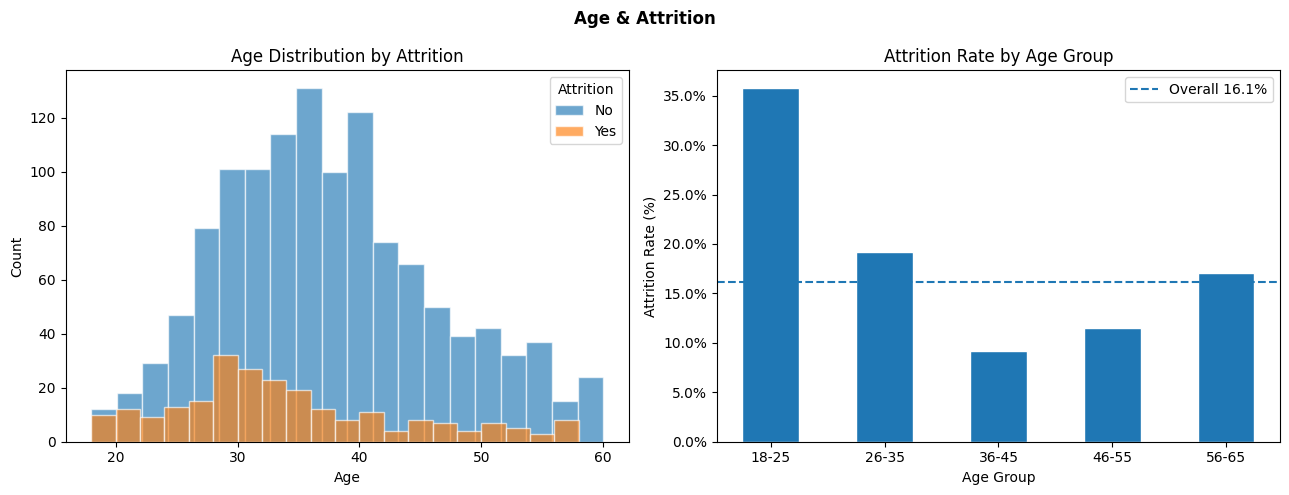

In [ ]:
# Plot the Age distribution against Attrition Count 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, grp in df.groupby('Attrition')['Age']:
    axes[0].hist(grp, bins=20, alpha=0.65, label=label, edgecolor='white')
axes[0].set_title('Age Distribution by Attrition')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend(title='Attrition')

# Age bucket attrition rate
df['AgeBucket'] = pd.cut(df['Age'], bins=[17,25,35,45,55,65],
                         labels=['18-25','26-35','36-45','46-55','56-65'])
age_rate = (df.groupby('AgeBucket')['AttritionBinary']
              .mean() * 100).reset_index()
age_rate.columns = ['AgeBucket', 'AttritionRate']

bars = axes[1].bar(age_rate['AgeBucket'].astype(str), age_rate['AttritionRate'], edgecolor='white', width=0.5)


axes[1].axhline(overall_rate, linestyle='--', label=f'Overall {overall_rate:.1f}%')
axes[1].legend()
axes[1].set_title('Attrition Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Age & Attrition', fontweight='bold')
plt.tight_layout()
plt.show()

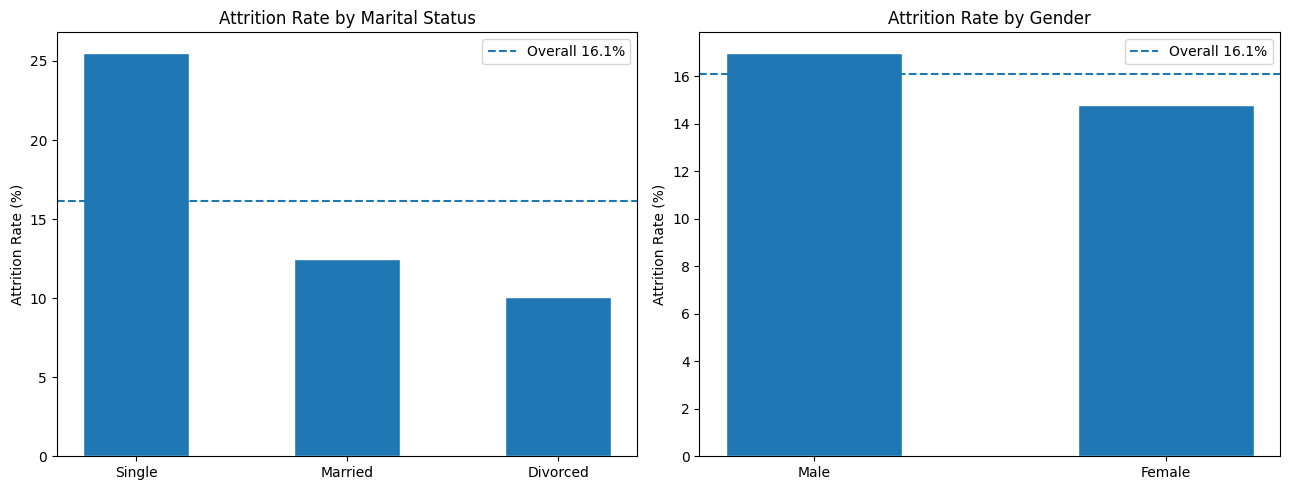

In [ ]:
# Marital Status & Gender
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(
        axes,
        ['MaritalStatus', 'Gender'],
        ['Attrition Rate by Marital Status', 'Attrition Rate by Gender']):

    rate = (df.groupby(col)['AttritionBinary'].mean() * 100).sort_values(ascending=False)
    bars = ax.bar(rate.index, rate.values, edgecolor='white', width=0.5)
    
    ax.axhline(overall_rate, linestyle='--', label=f'Overall {overall_rate:.1f}%')
    ax.legend()
    ax.set_title(title)
    ax.set_ylabel('Attrition Rate (%)')

plt.tight_layout()
plt.show()

**Insights:**
- Employees aged **18–25** have the highest attrition rate (~36%), likely due to early-career job-hopping.
- **Single** employees leave at nearly double the rate of married/divorced employees. It may be due to possible lower anchoring to location or lower family commitments.
- Little to no differences in Gender. 

### Exploring Job Role and Job Level


Attrition Rate by Job Role:
JobRole
Research Director             2.500000
Manager                       4.901961
Healthcare Representative     6.870229
Manufacturing Director        6.896552
Research Scientist           16.095890
Sales Executive              17.484663
Human Resources              23.076923
Laboratory Technician        23.938224
Sales Representative         39.759036

Attrition Rate by Job Level:
   JobLevel  AttritionRate
0         1      26.335175
1         2       9.737828
2         3      14.678899
3         4       4.716981
4         5       7.246377


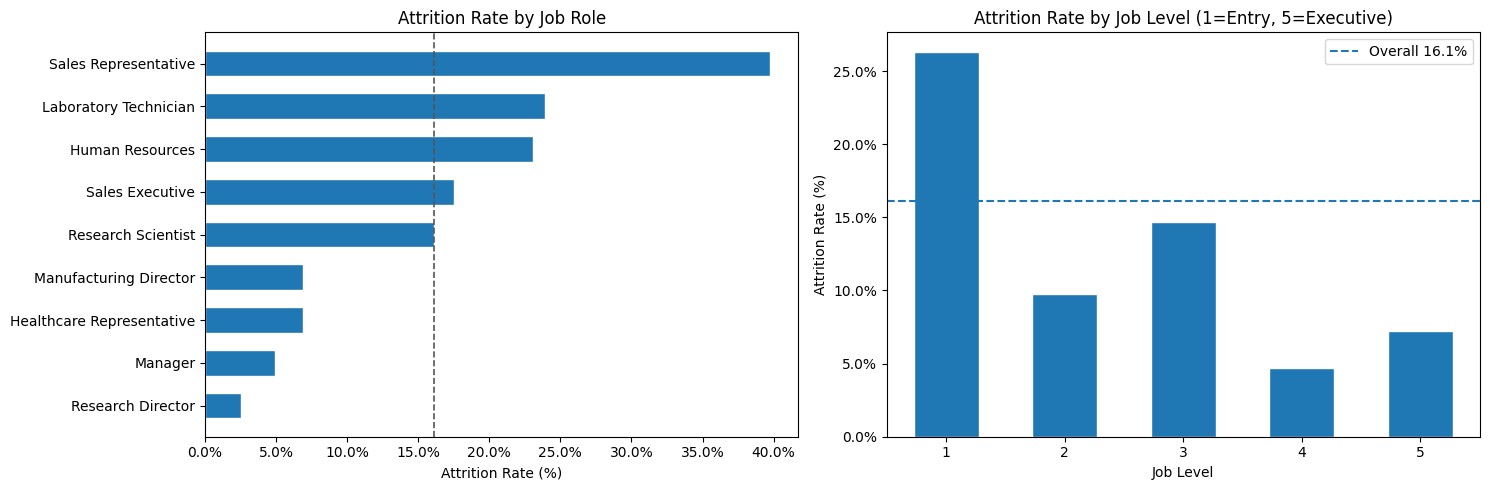

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Job Role
role_rate = (
    df.groupby('JobRole')['AttritionBinary']
      .mean() * 100
).sort_values(ascending=True)


axes[0].barh(role_rate.index, role_rate.values, edgecolor='white', height=0.6)
axes[0].axvline(overall_rate, color='#555', linestyle='--', linewidth=1.2)
axes[0].set_title('Attrition Rate by Job Role')
axes[0].set_xlabel('Attrition Rate (%)')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())

# Job Level
level_rate = (
    df.groupby('JobLevel')['AttritionBinary']
      .mean() * 100
).reset_index()
level_rate.columns = ['JobLevel', 'AttritionRate']

bars = axes[1].bar(level_rate['JobLevel'].astype(str),
                   level_rate['AttritionRate'],
                   edgecolor='white', width=0.55)

axes[1].axhline(overall_rate, linestyle='--', label=f'Overall {overall_rate:.1f}%')
axes[1].legend()
axes[1].set_title('Attrition Rate by Job Level (1=Entry, 5=Executive)')
axes[1].set_xlabel('Job Level')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())


print(f'\nAttrition Rate by Job Role:\n{role_rate.to_string()}')
print(f'\nAttrition Rate by Job Level:\n{level_rate.to_string()}')

plt.tight_layout()
plt.show()

**Insights:**
- **Sales Representatives** have disproportionately high attrition.
- **Level 1 (entry-level)** employees show the highest attrition. 

### Exploring Compensation Factors

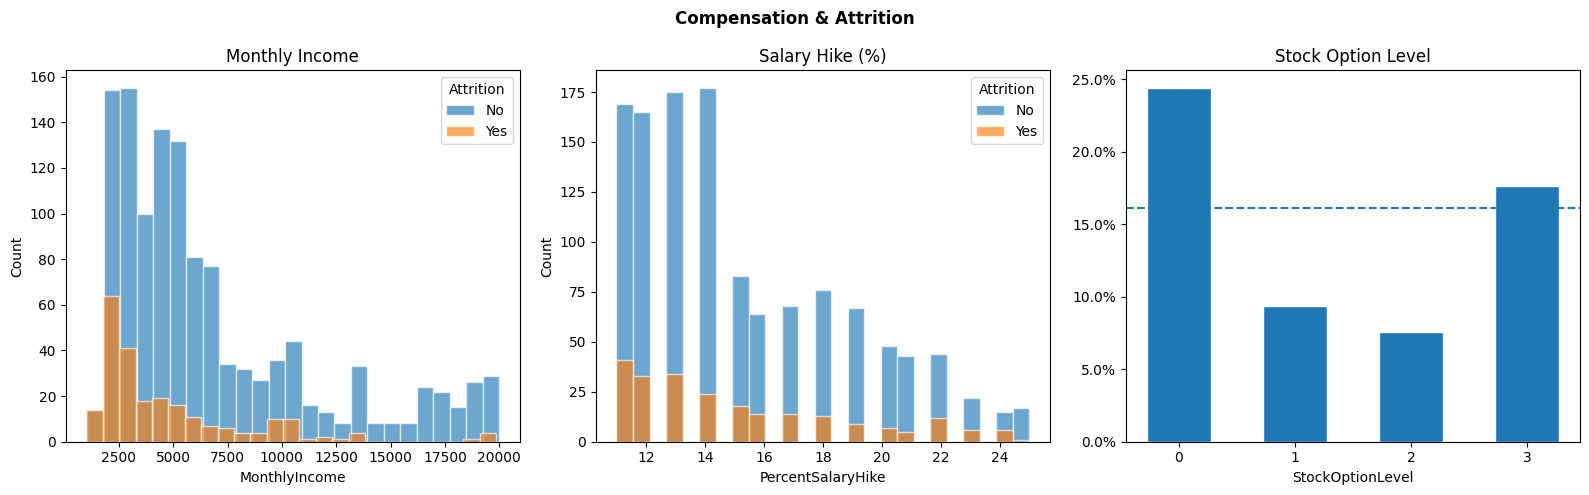

Median Monthly Income:
Attrition
No     5204.0
Yes    3202.0
Name: MonthlyIncome, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

comp_cols = ['MonthlyIncome', 'PercentSalaryHike', 'StockOptionLevel']
titles = ['Monthly Income', 'Salary Hike (%)', 'Stock Option Level']

for ax, col, title in zip(axes, comp_cols, titles):
    if col == 'StockOptionLevel':
        rate = df.groupby(col)['AttritionBinary'].mean() * 100
        bars = ax.bar(rate.index.astype(str), rate.values, edgecolor='white', width=0.55)
        ax.axhline(overall_rate, linestyle='--')
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    else:
        for label, grp in df.groupby('Attrition')[col]:
            ax.hist(grp, bins=25, alpha=0.65, label=label,edgecolor='white')
        ax.legend(title='Attrition')
        ax.set_ylabel('Count')

    ax.set_title(title)
    ax.set_xlabel(col)

plt.suptitle('Compensation & Attrition', fontweight='bold')
plt.tight_layout()
plt.show()

# Median income comparison
print('Median Monthly Income:')
print(df.groupby('Attrition')['MonthlyIncome'].median())

**Insights:**
- Employees who left have substantially **lower median monthly income** than those who stayed.
- **Stock option level 0** employees show significantly higher attrition, and this means that equity participation acts as a strong retention mechanism.
- Salary hike % shows limited differentiation but rather it's the base pay level that matters more than increment size.

### Exploring Work Environment & Satisfaction

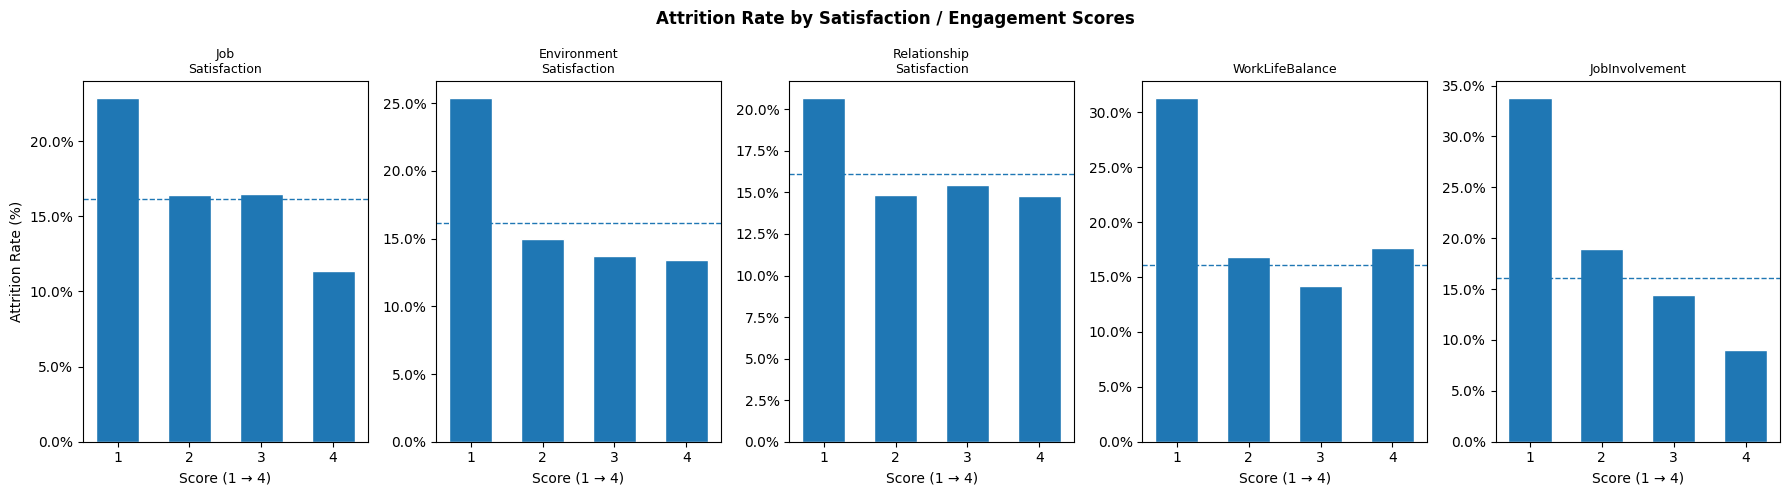

In [ ]:
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
            'RelationshipSatisfaction', 'WorkLifeBalance', 'JobInvolvement']

fig, axes = plt.subplots(1, len(sat_cols), figsize=(18, 5))

for ax, col in zip(axes, sat_cols):
    rate = df.groupby(col)['AttritionBinary'].mean() * 100
    bars = ax.bar(rate.index.astype(str), rate.values, edgecolor='white', width=0.6)
    ax.axhline(overall_rate, linestyle='--', linewidth=1)
    ax.set_title(col.replace('Satisfaction', '\nSatisfaction'), fontsize=9)
    ax.set_xlabel('Score (1 → 4)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    if ax == axes[0]:
        ax.set_ylabel('Attrition Rate (%)')

plt.suptitle('Attrition Rate by Satisfaction / Engagement Scores', fontweight='bold')
plt.tight_layout()
plt.show()

**Insights:**
- Across all satisfaction dimensions, **score = 1 (lowest)** consistently produces the highest attrition.
- **Job Involvement** shows the sharpest descent, as low-involvement employees (score 1) leave at ~35%, while highly involved employees (score 4) leave at ~9%.
- We can observe that the charts are not always linear, as medium satisfaction (score 2) sometimes has higher attrition than score 3. Engagement quality is just as important, not just satisfaction levels.

###  Exploring Overtime

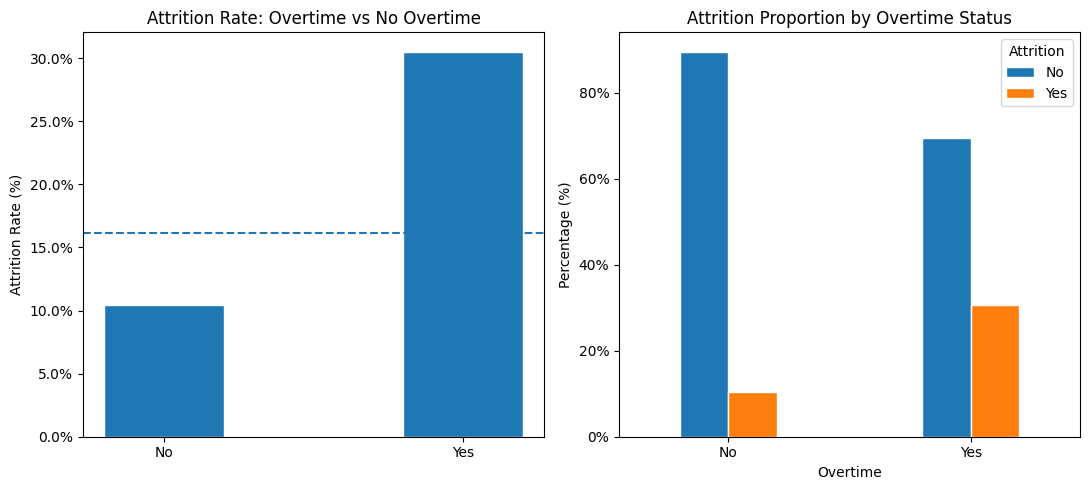

Attrition rates:
OverTime
No     10.436433
Yes    30.528846
Name: AttritionBinary, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ot_rate = df.groupby('OverTime')['AttritionBinary'].mean() * 100
bars = axes[0].bar(ot_rate.index, ot_rate.values, edgecolor='white', width=0.4)
axes[0].axhline(overall_rate, linestyle='--')
axes[0].set_title('Attrition Rate: Overtime vs No Overtime')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# Stacked bar — count breakdown
ct = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
ct.plot(kind='bar', ax=axes[1], edgecolor='white', width=0.4, legend=True)
axes[1].set_title('Attrition Proportion by Overtime Status')
axes[1].set_xlabel('Overtime')
axes[1].set_ylabel('Percentage (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Attrition')

plt.tight_layout()
plt.show()

print('Attrition rates:')
print(ot_rate)

**Insight:** Employees who work overtime leave at **~30%**, which is nearly 3× the rate of those who don't (~10%). Overtime is one of the strongest individual predictors of attrition.

### Exploring Tenure & Career Progression

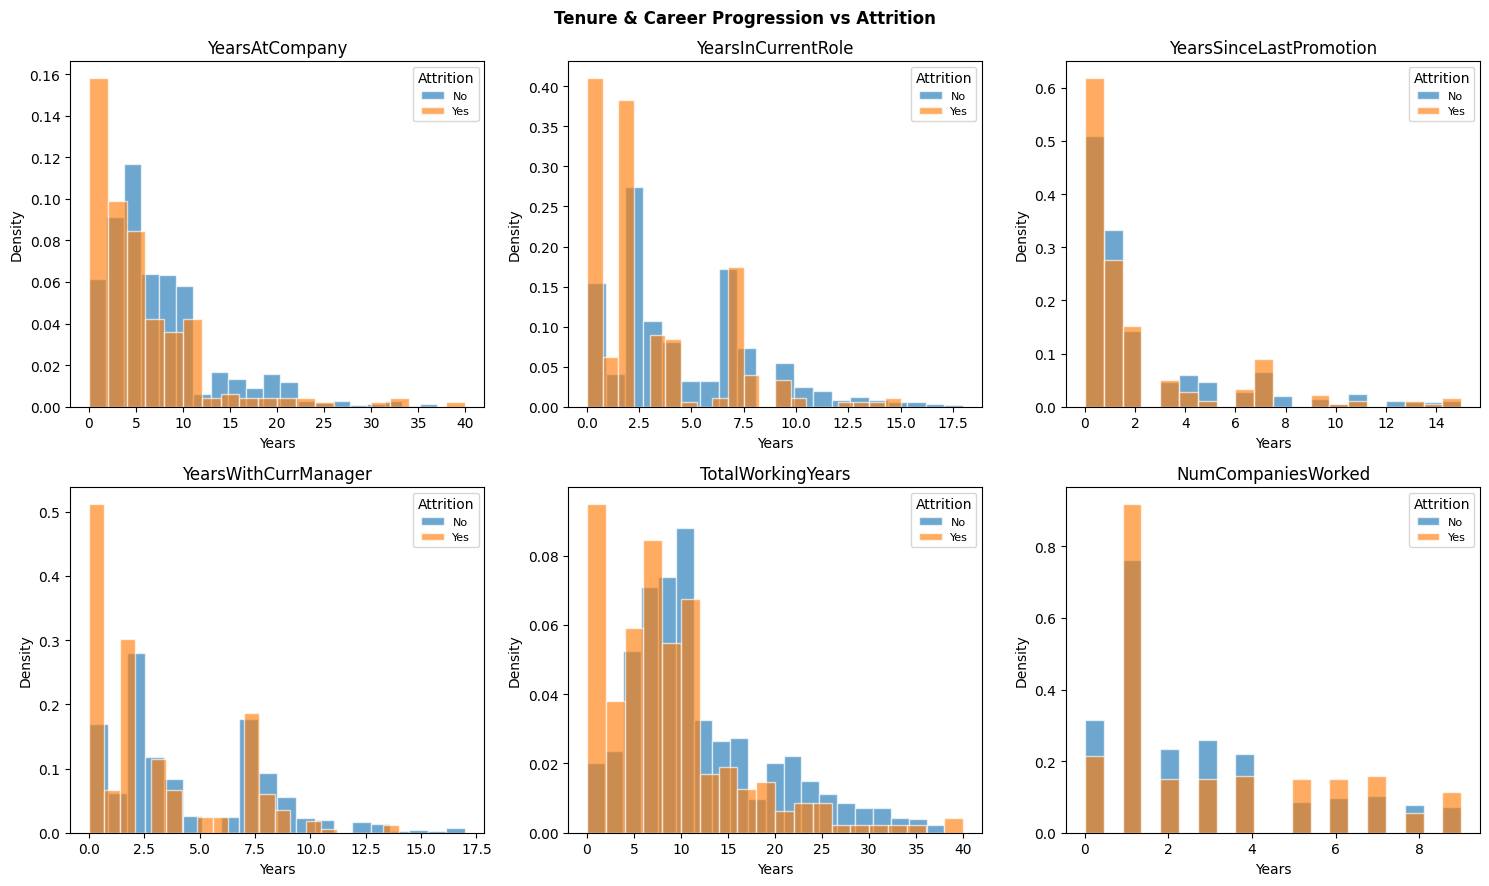

Mean tenure by attrition:
Attrition                  No  Yes
YearsAtCompany            7.4  5.1
YearsInCurrentRole        4.5  2.9
YearsSinceLastPromotion   2.2  1.9
YearsWithCurrManager      4.4  2.9
TotalWorkingYears        11.9  8.2
NumCompaniesWorked        2.6  2.9


In [ ]:
tenure_cols = ['YearsAtCompany', 'YearsInCurrentRole',
               'YearsSinceLastPromotion', 'YearsWithCurrManager',
               'TotalWorkingYears', 'NumCompaniesWorked']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, col in zip(axes, tenure_cols):
    for label, grp in df.groupby('Attrition')[col]:
        ax.hist(grp, bins=20, alpha=0.65, label=label, edgecolor='white', density=True)
    ax.set_title(col)
    ax.set_xlabel('Years')
    ax.set_ylabel('Density')
    ax.legend(title='Attrition', fontsize=8)

plt.suptitle('Tenure & Career Progression vs Attrition', fontweight='bold')
plt.tight_layout()
plt.show()

print('Mean tenure by attrition:')
print(df.groupby('Attrition')[tenure_cols].mean().round(1).T)

**Insights:**
- Employees who left had **fewer years at the company** (avg ~5 vs ~7), **less total working experience**, and had worked at **more companies** previously, has higher levels of attrition. This suggests job-hopping. 
- Early tenure (0–2 years) is the highest-risk window, pointing to a critical onboarding/early engagement gap.

### Exploring Distance from Home and Business Travel

Max Distance from Home: 29
Min Distance from Home: 1


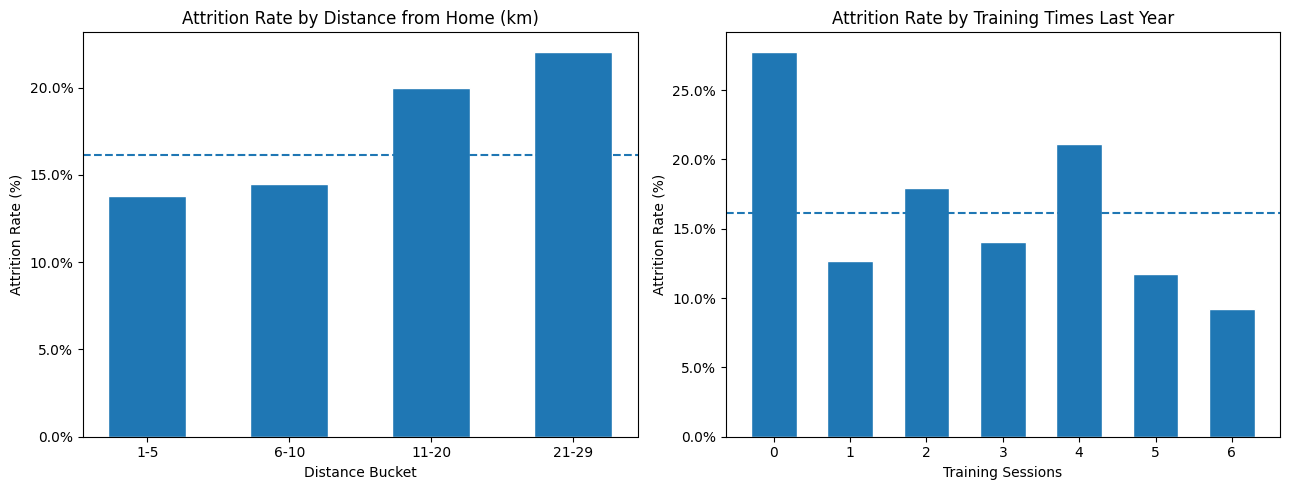

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

print(f'Max Distance from Home: {df["DistanceFromHome"].max()}')
print(f'Min Distance from Home: {df["DistanceFromHome"].min()}')

# Distance buckets from 0 to 30 km 
df['DistanceBucket'] = pd.cut(df['DistanceFromHome'],
                               bins=[0,5,10,20,30],
                               labels=['1-5','6-10','11-20','21-29'])
                               
dist_rate = df.groupby('DistanceBucket')['AttritionBinary'].mean() * 100
axes[0].bar(dist_rate.index.astype(str),dist_rate.values, edgecolor='white', width=0.55)
axes[0].axhline(overall_rate, linestyle='--')
axes[0].set_title('Attrition Rate by Distance from Home (km)')
axes[0].set_xlabel('Distance Bucket')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# Training times
train_rate = df.groupby('TrainingTimesLastYear')['AttritionBinary'].mean() * 100
axes[1].bar(train_rate.index.astype(str), train_rate.values, edgecolor='white', width=0.6)
axes[1].axhline(overall_rate, linestyle='--')
axes[1].set_title('Attrition Rate by Training Times Last Year')
axes[1].set_xlabel('Training Sessions')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

**Insights:**
- Longer commutes correlate with higher attrition, so employees living far from the workplace are less likely to stay.
- Employees with **0 or 1 training sessions** show higher attrition than those trained 2–4 times, it is therefore important to shift investment in learning in order to reduce turnover.


### Correlation Heatmap (Numerical Features)

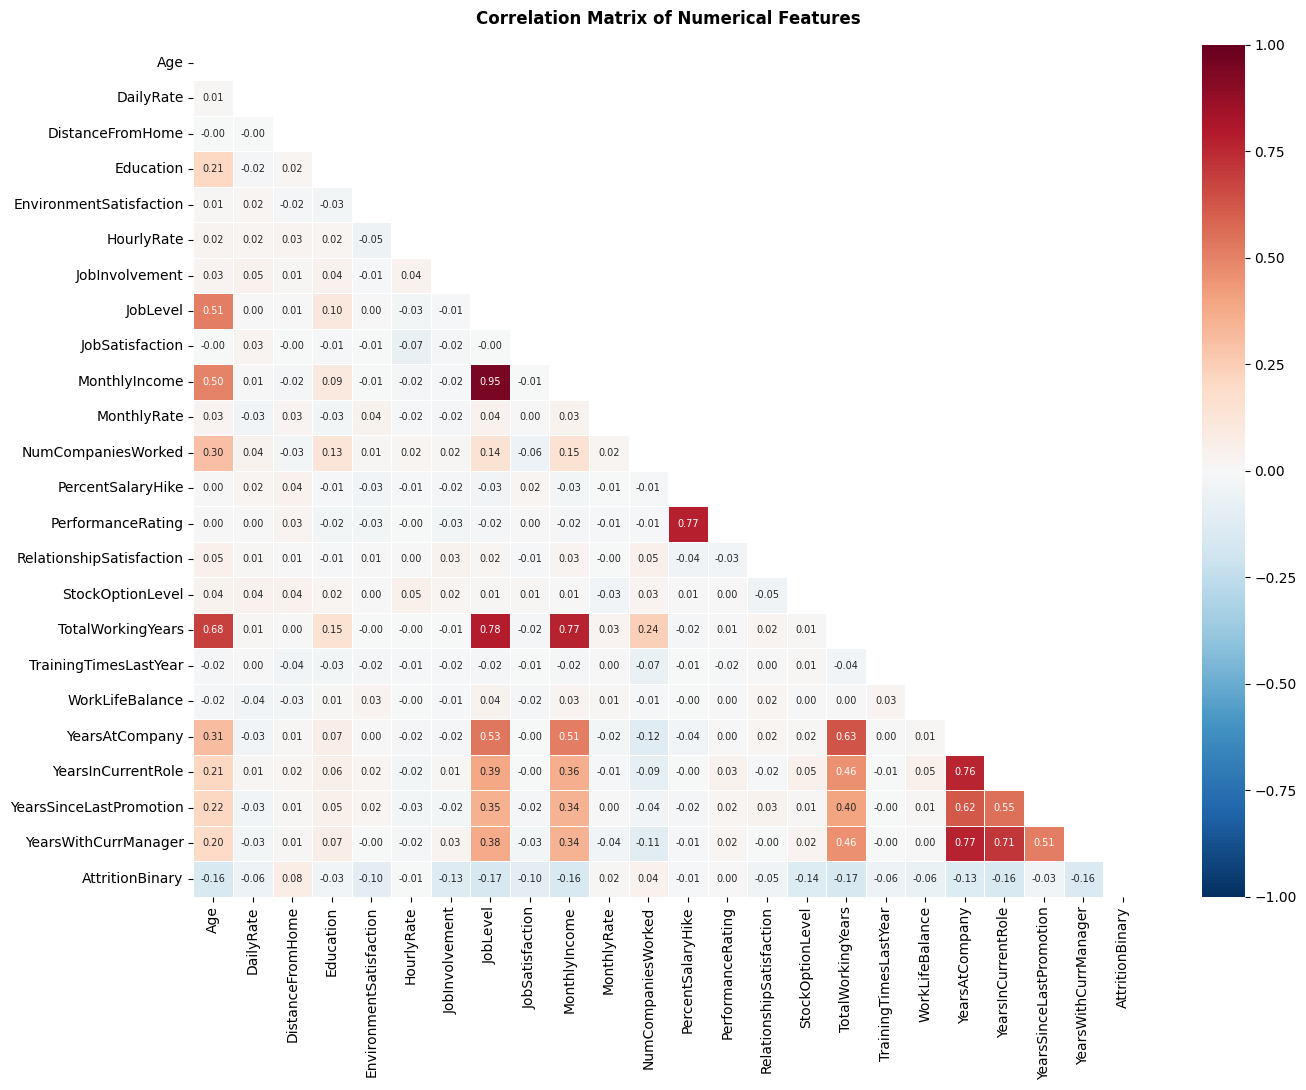

Top 10 features correlated with Attrition:
TotalWorkingYears      -0.171
JobLevel               -0.169
YearsInCurrentRole     -0.161
MonthlyIncome          -0.160
Age                    -0.159
YearsWithCurrManager   -0.156
StockOptionLevel       -0.137
YearsAtCompany         -0.134
JobInvolvement         -0.130
JobSatisfaction        -0.103
Name: AttritionBinary, dtype: float64


In [ ]:
num_cols = df.select_dtypes(include=np.number).drop(
    columns=['EmployeeNumber', 'StandardHours']).columns.tolist()

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 7}, linewidths=0.5)
ax.set_title('Correlation Matrix of Numerical Features', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top correlations with AttritionBinary
corr_target = corr['AttritionBinary'].drop('AttritionBinary').sort_values(key=abs, ascending=False)
print('Top 10 features correlated with Attrition:')
print(corr_target.head(10).round(3))

#### We look at the negative correlations as they are the **retention drivers**. Stability, income as well as experience plays a strong role in keeping people in the company. 

## Top Attrition Risk Factors

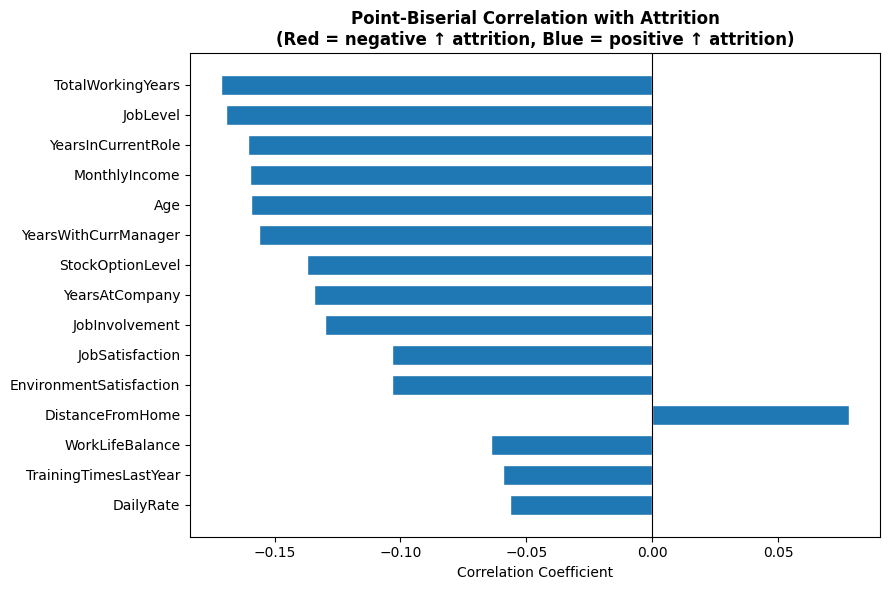

                Feature  Correlation      p_value
      TotalWorkingYears    -0.171063 4.061878e-11
               JobLevel    -0.169105 6.795385e-11
     YearsInCurrentRole    -0.160545 6.003186e-10
          MonthlyIncome    -0.159840 7.147364e-10
                    Age    -0.159205 8.356308e-10
   YearsWithCurrManager    -0.156199 1.736987e-09
       StockOptionLevel    -0.137145 1.301015e-07
         YearsAtCompany    -0.134392 2.318872e-07
         JobInvolvement    -0.130016 5.677065e-07
        JobSatisfaction    -0.103481 7.043067e-05
EnvironmentSatisfaction    -0.103369 7.172339e-05
       DistanceFromHome     0.077924 2.793060e-03
        WorkLifeBalance    -0.063939 1.421105e-02
  TrainingTimesLastYear    -0.059478 2.257850e-02
              DailyRate    -0.056652 2.985816e-02


In [ ]:
# Point-biserial correlation between AttritionBin and all numeric features
from scipy.stats import pointbiserialr

results = []
for col in num_cols:
    if col == 'AttritionBinary':
        continue
    r, p = pointbiserialr(df['AttritionBinary'], df[col])
    results.append({'Feature': col, 'Correlation': r, 'p_value': p})

corr_df = pd.DataFrame(results).sort_values('Correlation', key=abs, ascending=False)
top15 = corr_df.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top15['Feature'][::-1], top15['Correlation'][::-1], edgecolor='white', height=0.65)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Point-Biserial Correlation with Attrition\n(Red = negative ↑ attrition, Blue = positive ↑ attrition)',
             fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(top15[['Feature','Correlation','p_value']].to_string(index=False))

## 3. Key EDA Takeaway (Summary)

| Driver | Finding | HR Implication |
|---|---|---|
| **Overtime** | OT employees are more likely to leave the company | Review workload distribution |
| **Job Level** | Level 1 attrition ≈ 26% | Give better benefits for newcomers|
| **Monthly Income** | Leavers earn significantly lesser compared to others | Employ competitive compensation |
| **Stock Options** | Level 0 stock has highest attrition | Expand equity participation |
| **Age / Tenure** | Younger and short-tenure employees are at risk | Have targeted onboarding and engagement |
| **Job Involvement** | Low involvement has higher attrition| Role enrichment and meaningful work |
| **Distance from Home** | Longer commute leads to higher attrition | Flexible work and hybrid policies |
| **Department** | Sales highest; R&D lowest | Tailor retention by department |

> **Next Step:** These drivers will inform feature selection and interpretation for the predictive models in Part 2.